In [1]:
import scanpy as sc
import celltypist
import time
import numpy as np
import pandas as pd
import os
from celltypist import models
import scvi
from sklearn_ann.kneighbors.annoy import AnnoyTransformer
from multiprocessing import Pool
import cosg
sc.settings.set_figure_params(dpi=100, fontsize=10, dpi_save=400,
    facecolor = 'white', figsize=(8,8), format='pdf')
import matplotlib as mpl
import matplotlib.font_manager as fm
mpl.rcParams['pdf.fonttype'] = 42
fm.fontManager.addfont("fonts/arial.ttf")
mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['lines.linewidth'] = 0.5

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
adata = sc.read_h5ad('/home/liyanguo/MyImmuCell/05_Ref_Atlas_subpopulation/Level2_Refine_R1/Celltype_L1_L2_Refine_R1.h5ad')

In [3]:
adata.obs['Celltype_L1_L2_Refine'].value_counts()

Celltype_L1_L2_Refine
NDNs                         240522
CD4+ T cells                 158168
Non-MAIT/NKT CD8+ T cells    114555
NK cells                      79020
Classical monocytes           44552
B cells                       28220
MAIT                          17983
Non-classical monocytes       15652
γδ T cells                     5109
cDCs                           3096
Proliferative T/NK             2341
Plamsa cells                   1842
Basophils                      1769
pDCs                           1699
LDNs                           1645
Platelets                      1189
HSPC                            261
Mast                             58
iNKT                             42
Name: count, dtype: int64

In [4]:
adata_raw = adata[adata.obs['Celltype_L1_L2_Refine']=='LDNs',].copy()
adata_raw = adata_raw[adata_raw.obs['type']=='PBMC',].copy()

In [7]:
adata = adata_raw.copy()

In [8]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,flavor='seurat_v3',n_top_genes=2000,layer="counts",
                        subset=True)

In [9]:
adata.X.max()

np.float32(8.103466)

In [10]:
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key ="Batch",
    continuous_covariate_keys=["nCount_RNA", "percent_mito"]
)

In [11]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30, gene_likelihood="nb")

model.train(accelerator="cpu",
            max_epochs=200)

INFO: GPU available: False, used: False
GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
HPU available: False, using: 0 HPUs


Training:   0%|          | 0/200 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
`Trainer.fit` stopped: `max_epochs=200` reached.


In [12]:
adata.obsm["X_scVI"]=model.get_latent_representation()

In [13]:
sc.pp.neighbors(adata, transformer=AnnoyTransformer(20), use_rep='X_scVI')

In [14]:
sc.tl.umap(adata, min_dist=0.5)

In [15]:
def run_leiden_parallel(params):
    global adata
    key_added = f"leiden_scVI_{params['resolution']}"
    sc.tl.leiden(adata, key_added=f'leiden_scVI_{params['resolution']}', 
                 **params,
                 use_weights=True,directed=False,flavor="igraph")
    return {key_added: adata.obs[key_added]}

In [16]:
param = [
        {"resolution": 0.5},
        {"resolution": 1},
        {"resolution": 1.5},
        {"resolution": 2},
]

In [17]:
with Pool(4) as p:
    leiden_columns = p.map(run_leiden_parallel, param)

In [18]:
for col_dict in leiden_columns:
    for key, values in col_dict.items():
        adata.obs[key] = values

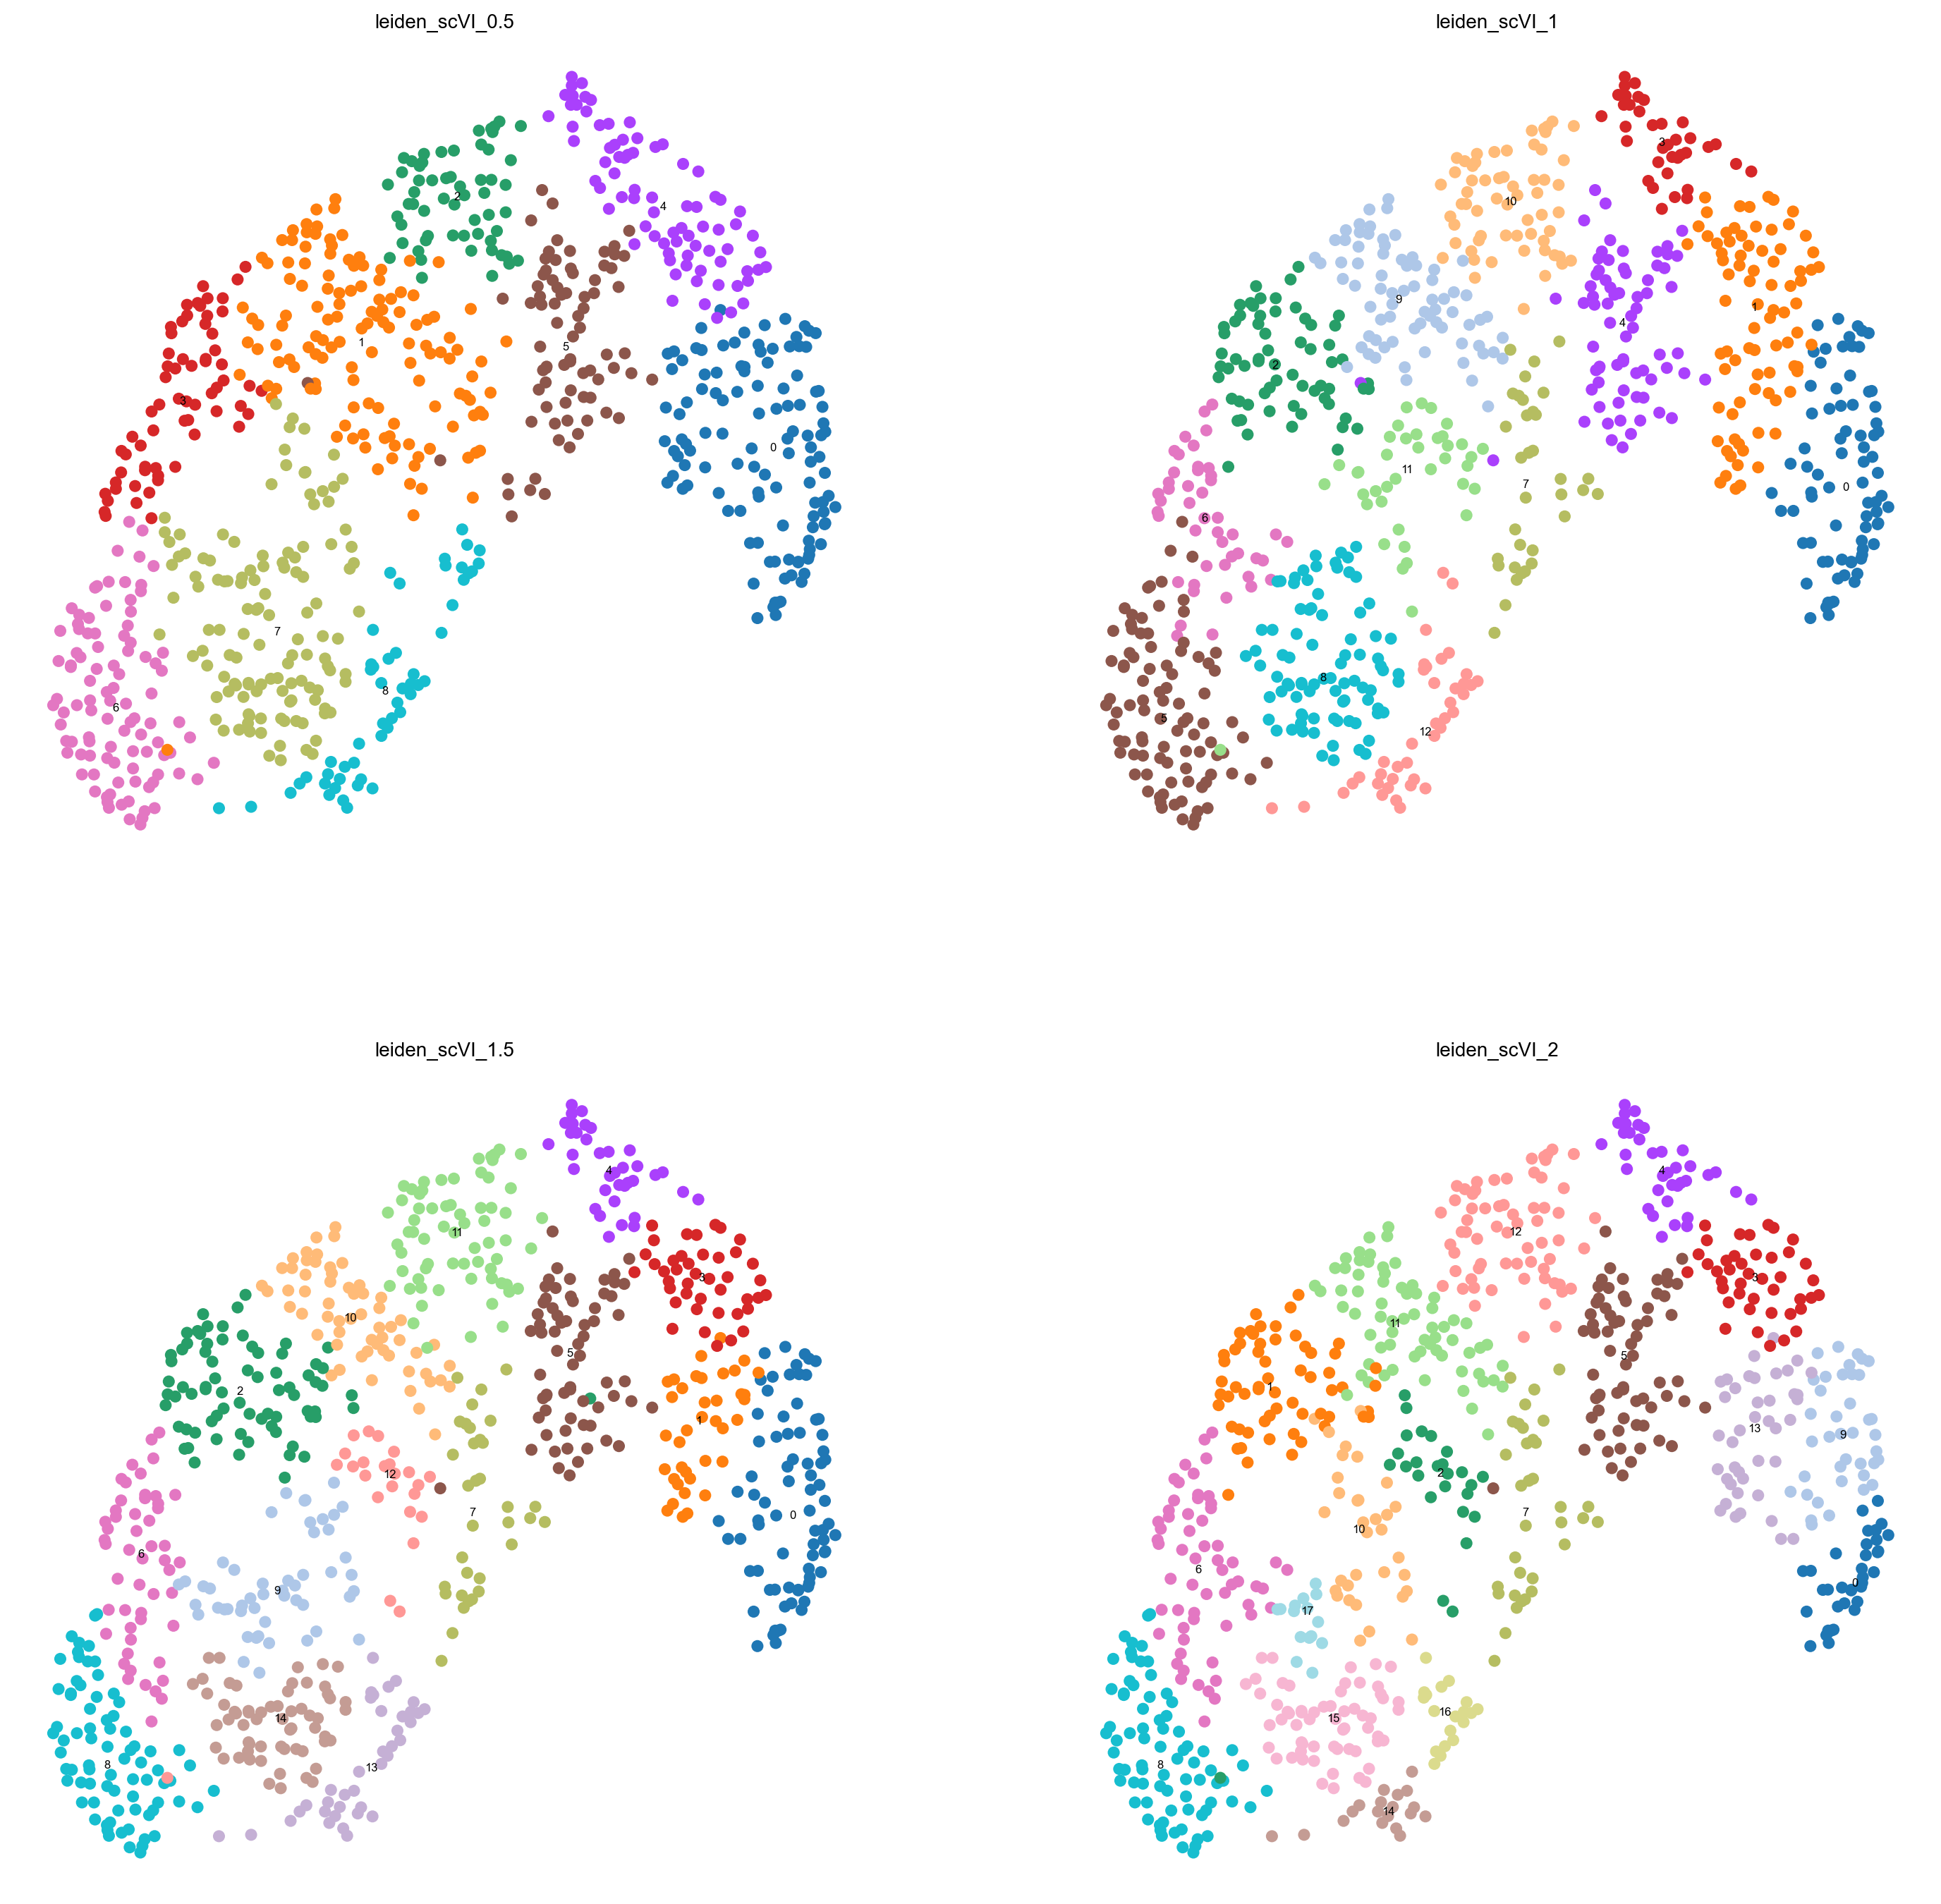

In [19]:
sc.pl.umap(
    adata,
    color=['leiden_scVI_0.5','leiden_scVI_1','leiden_scVI_1.5','leiden_scVI_2',],
    legend_fontsize=6,legend_loc='on data',ncols=2,frameon=False
)

In [20]:
adata.raw = adata_raw

In [21]:
adata = adata.raw.to_adata()

In [22]:
adata.X.max()

np.float32(2519.0)

In [23]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [24]:
marker_dict1={
    'Immune cell': ['PTPRC'],
    'Lineage':['CD7','CD3E',
               'IL7R',
               'SPON2','KLRF1',
               'CD79A','MS4A1',
               'CD14','FCGR3A',
               'CSF3R','FCGR3B'
              ],
    'HSPC':['CD34','SPINK2',],
    'Basophil':['HDC','GATA2', 'FCER1A'],

    'NDNs':['FCGR3B','CSF3R','MME','G0S2','MNDA','CEBPB'],
    'LDNs':['CEACAM8','LTF','BPI','MPO','ELANE','CEBPE'],
    'Classical monocytes' :['CD14','LYZ','VCAN','FCN1',],
}

In [26]:
adata.obs['leiden_scVI_0.5'].value_counts()

leiden_scVI_0.5
1    129
7    122
0    115
6     98
4     78
5     77
3     65
2     58
8     52
Name: count, dtype: int64

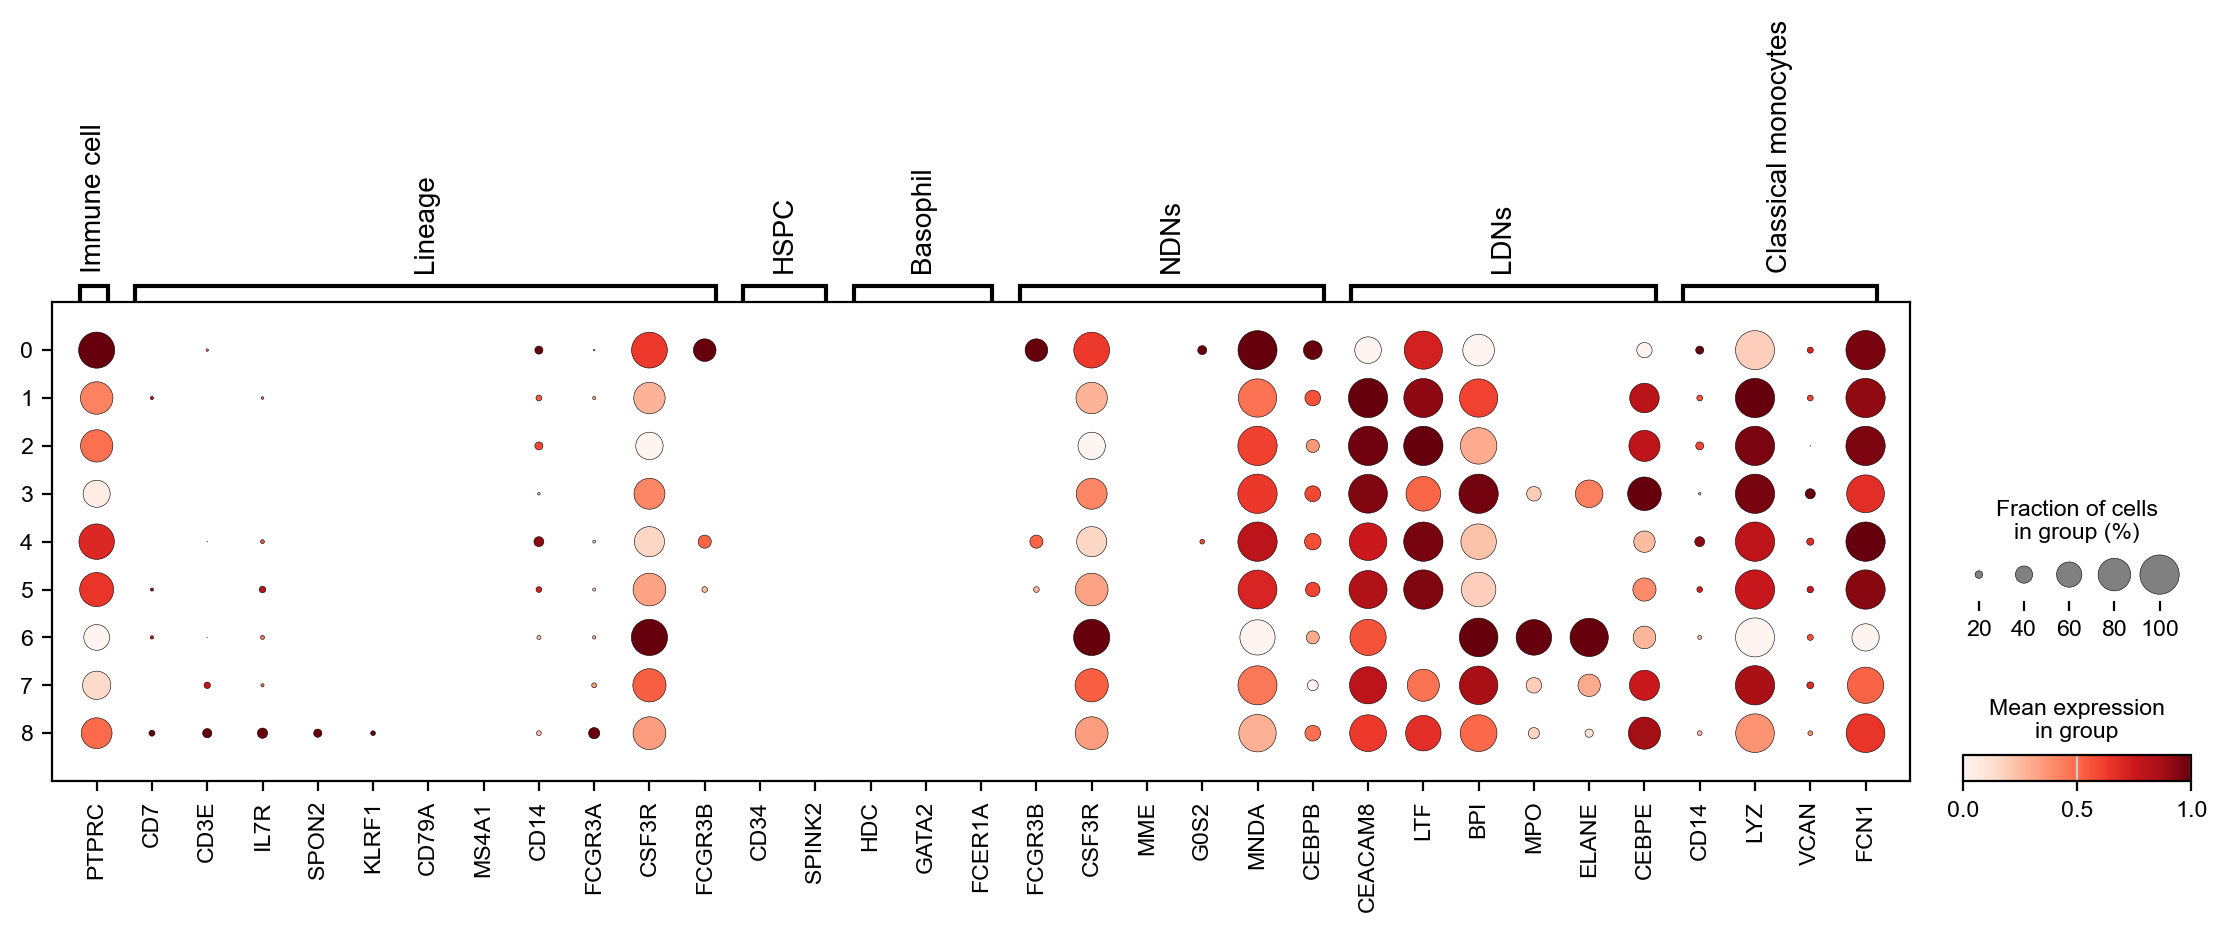

In [25]:
sc.pl.dotplot(
    adata,
    groupby='leiden_scVI_0.5',
    var_names=marker_dict1,
    standard_scale='var',
    dot_min=0.1
)